In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

# 讀取數據集
data = pd.read_csv("GDM_Model1.csv")

In [2]:
#數據分割
#將數據集分為訓練集和測試集
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [3]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9769 entries, 9598 to 7270
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9769 non-null   int64  
 1   Weight                 9769 non-null   float64
 2   Height                 9769 non-null   float64
 3   BMI                    9769 non-null   float64
 4   Ethnicity              9769 non-null   int64  
 5   Gravida                9769 non-null   int64  
 6   Glucoselevel0minblood  9769 non-null   float64
 7   GDM                    9769 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 686.9 KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2443 entries, 2919 to 3794
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    2443 non-null   int64  
 1   Weight                 2443 non-null   float64
 2

0    8859
1     910
Name: GDM, dtype: int64


<AxesSubplot: xlabel='GDM', ylabel='count'>

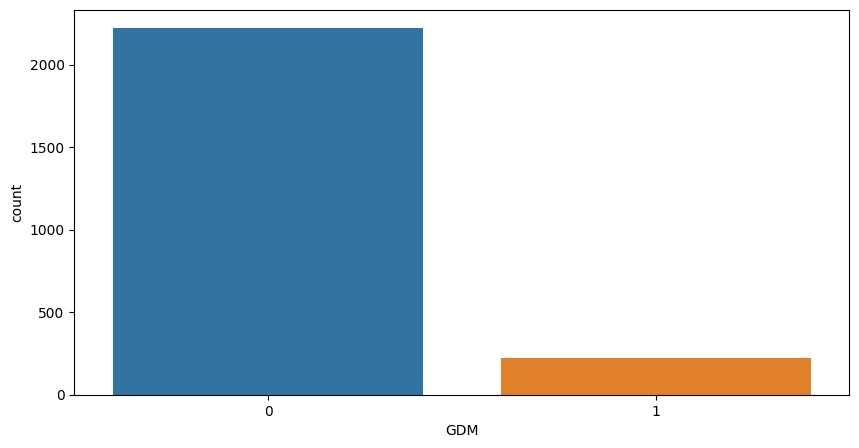

In [4]:
#Y/N個數
fig, ax =plt.subplots(figsize=(10,5))
print(train_data.GDM.value_counts())

sns.countplot(data=test_data,x='GDM',ax=ax)

In [5]:
#模型選擇
from pycaret.classification import *

#初始化PyCaret
#setup(data=train_data, target='GDM', session_id=42)
clf1 = setup(data=train_data, 
             target='GDM', 
             fold_shuffle=True, 
             session_id=2, 
             preprocess=False)

#排除模型
exclude_models = ['ridge','dummy']

#比較不同的分類器
best_model = compare_models() #best_model = compare_models() #

,Description,Value
0,Session id,2
1,Target,GDM
2,Target type,Binary
3,Original data shape,"(9769, 8)"
4,Transformed data shape,"(9769, 8)"
5,Transformed train set shape,"(6838, 8)"
6,Transformed test set shape,"(2931, 8)"
7,Numeric features,7


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9706,0.8762,0.6844,1.0000,0.8094,0.7943,0.8127,0.3700
gbc,Gradient Boosting Classifier,0.9699,0.8925,0.6859,0.9868,0.8060,0.7904,0.8075,0.3120
lightgbm,Light Gradient Boosting Machine,0.9699,0.8804,0.6859,0.9865,0.8060,0.7905,0.8075,0.4440
ada,Ada Boost Classifier,0.9696,0.8846,0.6812,0.9888,0.8032,0.7875,0.8054,0.1800
xgboost,Extreme Gradient Boosting,0.9691,0.8732,0.6859,0.9761,0.8023,0.7863,0.8025,0.3320
et,Extra Trees Classifier,0.9637,0.8780,0.6121,0.9976,0.7532,0.7353,0.7636,0.3410
lr,Logistic Regression,0.9571,0.8798,0.5447,0.9903,0.7001,0.6794,0.7160,1.1000
lda,Linear Discriminant Analysis,0.9560,0.8755,0.5290,0.9958,0.6869,0.6660,0.7066,0.0990
qda,Quadratic Discriminant Analysis,0.9357,0.8656,0.5588,0.6945,0.6175,0.5830,0.5880,0.0610
dt,Decision Tree Classifier,0.9323,0.8302,0.7048,0.6220,0.6591,0.6218,0.6243,0.0410


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [6]:
#模型訓練
#提取前5個及各分數最高的模型建立
#lr = create_model('lr')
#lda = create_model('lda')
xgboost = create_model('xgboost')
rf = create_model('rf')
ada = create_model('ada')
gbc = create_model('gbc')
lightgbm = create_model('lightgbm')
#ridge = create_model('ridge')
#dt = create_model('dt')
#dummy = create_model('dummy')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9635,0.8507,0.6250,0.9756,0.7619,0.7431,0.7648
1,0.9708,0.8845,0.7344,0.9400,0.8246,0.8089,0.8162
2,0.9737,0.8844,0.7344,0.9792,0.8393,0.8253,0.8354
3,0.9766,0.9141,0.7500,1.0000,0.8571,0.8447,0.8551
4,0.9751,0.8930,0.7500,0.9796,0.8496,0.8363,0.8451
5,0.9708,0.8910,0.7188,0.9583,0.8214,0.8059,0.8158
6,0.9561,0.8149,0.5625,0.9474,0.7059,0.6838,0.7111
7,0.9825,0.9368,0.8254,0.9811,0.8966,0.8870,0.8910
8,0.9634,0.8196,0.6032,1.0000,0.7525,0.7340,0.7614


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9649,0.8555,0.6250,1.0000,0.7692,0.7513,0.7757
1,0.9751,0.9041,0.7344,1.0000,0.8468,0.8337,0.8454
2,0.9751,0.9014,0.7344,1.0000,0.8468,0.8337,0.8454
3,0.9766,0.9133,0.7500,1.0000,0.8571,0.8447,0.8551
4,0.9766,0.9036,0.7500,1.0000,0.8571,0.8447,0.8551
5,0.9722,0.8917,0.7031,1.0000,0.8257,0.8111,0.8260
6,0.9591,0.8150,0.5625,1.0000,0.7200,0.6998,0.7336
7,0.9839,0.9321,0.8254,1.0000,0.9043,0.8957,0.9006
8,0.9634,0.8585,0.6032,1.0000,0.7525,0.7340,0.7614


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9620,0.8589,0.6094,0.9750,0.7500,0.7306,0.7543
1,0.9722,0.9120,0.7344,0.9592,0.8319,0.8170,0.8257
2,0.9751,0.8940,0.7344,1.0000,0.8468,0.8337,0.8454
3,0.9766,0.9194,0.7500,1.0000,0.8571,0.8447,0.8551
4,0.9766,0.8978,0.7500,1.0000,0.8571,0.8447,0.8551
5,0.9722,0.9029,0.7031,1.0000,0.8257,0.8111,0.8260
6,0.9576,0.8251,0.5469,1.0000,0.7071,0.6863,0.7228
7,0.9825,0.9505,0.8254,0.9811,0.8966,0.8870,0.8910
8,0.9634,0.8410,0.6032,1.0000,0.7525,0.7340,0.7614


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9649,0.8732,0.6250,1.0000,0.7692,0.7513,0.7757
1,0.9737,0.9101,0.7344,0.9792,0.8393,0.8253,0.8354
2,0.9751,0.9002,0.7344,1.0000,0.8468,0.8337,0.8454
3,0.9766,0.9016,0.7500,1.0000,0.8571,0.8447,0.8551
4,0.9766,0.9114,0.7500,1.0000,0.8571,0.8447,0.8551
5,0.9722,0.9207,0.7188,0.9787,0.8288,0.8141,0.8256
6,0.9576,0.8372,0.5625,0.9730,0.7129,0.6917,0.7221
7,0.9810,0.9578,0.8254,0.9630,0.8889,0.8786,0.8817
8,0.9619,0.8523,0.6032,0.9744,0.7451,0.7258,0.7502


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9649,0.8646,0.6250,1.0000,0.7692,0.7513,0.7757
1,0.9722,0.8948,0.7344,0.9592,0.8319,0.8170,0.8257
2,0.9737,0.8867,0.7344,0.9792,0.8393,0.8253,0.8354
3,0.9766,0.9069,0.7500,1.0000,0.8571,0.8447,0.8551
4,0.9751,0.9085,0.7500,0.9796,0.8496,0.8363,0.8451
5,0.9737,0.9110,0.7188,1.0000,0.8364,0.8225,0.8357
6,0.9561,0.8250,0.5625,0.9474,0.7059,0.6838,0.7111
7,0.9839,0.9411,0.8254,1.0000,0.9043,0.8957,0.9006
8,0.9634,0.8219,0.6032,1.0000,0.7525,0.7340,0.7614


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
stacker1_3 = stack_models(estimator_list = [xgboost,rf,ada,gbc,lightgbm], meta_model =rf ) #

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9635,0.8430,0.6094,1.0000,0.7573,0.7388,0.7653
1,0.9751,0.8851,0.7344,1.0000,0.8468,0.8337,0.8454
2,0.9751,0.8791,0.7344,1.0000,0.8468,0.8337,0.8454
3,0.9766,0.8836,0.7500,1.0000,0.8571,0.8447,0.8551
4,0.9766,0.9112,0.7500,1.0000,0.8571,0.8447,0.8551
5,0.9722,0.8603,0.7031,1.0000,0.8257,0.8111,0.8260
6,0.9576,0.8210,0.5469,1.0000,0.7071,0.6863,0.7228
7,0.9810,0.9404,0.8254,0.9630,0.8889,0.8786,0.8817
8,0.9634,0.8349,0.6032,1.0000,0.7525,0.7340,0.7614


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

In [8]:
#stacker1_1 = stack_models(estimator_list = [lda,ada,lr,gbc,lightgbm], meta_model =lr ) #
stacker1_3

StackingClassifier(cv=5,
                   estimators=[('Extreme Gradient Boosting',
                                XGBClassifier(base_score=None, booster='gbtree',
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              gpu_id=None, grow_policy=None,
                                              importance_type=None,
                                              interacti...
                                                          ccp_alpha=0.0,
                                                          class_weight=None,
                                                          criterion='gini',
                                                          max_depth=None,
                                                          max_features='sqrt',
                                                          max_leaf_nodes=None,
                                                          max_samples=None,
                                                          min_impurity_decrease=0.0,
                                                          min_samples_leaf=1,
                                                          min_samples_split=2,
                                                          min_weight_fraction_leaf=0.0,
                                                          n_estimators=100,
                                                          n_jobs=-1,
                                                          oob_score=False,
                                                          random_state=2,
                                                          verbose=0,
                                                          warm_start=False),
                   n_jobs=-1, passthrough=True, stack_method='auto', verbose=0)

In [9]:
stacker_model = tune_model(stacker1_3)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9635,0.8783,0.6094,1.0000,0.7573,0.7388,0.7653
1,0.9751,0.9129,0.7344,1.0000,0.8468,0.8337,0.8454
2,0.9751,0.9008,0.7344,1.0000,0.8468,0.8337,0.8454
3,0.9766,0.9030,0.7500,1.0000,0.8571,0.8447,0.8551
4,0.9766,0.9115,0.7500,1.0000,0.8571,0.8447,0.8551
5,0.9722,0.9189,0.7031,1.0000,0.8257,0.8111,0.8260
6,0.9576,0.8446,0.5469,1.0000,0.7071,0.6863,0.7228
7,0.9839,0.9629,0.8254,1.0000,0.9043,0.8957,0.9006
8,0.9634,0.8548,0.6032,1.0000,0.7525,0.7340,0.7614


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [10]:
stacker_model

StackingClassifier(cv=5,
                   estimators=[('Extreme Gradient Boosting',
                                XGBClassifier(base_score=None, booster='gbtree',
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              gpu_id=None, grow_policy=None,
                                              importance_type=None,
                                              interacti...
                                                          ccp_alpha=0.0,
                                                          class_weight={},
                                                          criterion='entropy',
                                                          max_depth=3,
                                                          max_features=1.0,
                                                          max_leaf_nodes=None,
                                                          max_samples=None,
                                                          min_impurity_decrease=0,
                                                          min_samples_leaf=5,
                                                          min_samples_split=7,
                                                          min_weight_fraction_leaf=0.0,
                                                          n_estimators=50,
                                                          n_jobs=-1,
                                                          oob_score=False,
                                                          random_state=2,
                                                          verbose=0,
                                                          warm_start=False),
                   n_jobs=-1, passthrough=True, stack_method='auto', verbose=0)

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

...

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

In [19]:
#save_model(stacker_model,'stacker_model1_1')
save_model(stacker_model,'stacker1_3')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=FastMemory(location=C:\Users\User\AppData\Local\Temp\joblib),
          steps=[('placeholder', None),
                 ('trained_model',
                  StackingClassifier(cv=5,
                                     estimators=[('Extreme Gradient Boosting',
                                                  XGBClassifier(base_score=None,
                                                                booster='gbtree',
                                                                callbacks=None,
                                                                colsample_bylevel=None,
                                                                colsample_bynode=None,
                                                                colsample_bytree=None,
                                                                early_stopping_rounds=None,
                                                                enable_ca...
                                                  

In [20]:
#model1_1 = load_model('stacker_model1_1')
#model1_2 = load_model('stacker_model1_2')
model1_3 = load_model('stacker1_3')
#pred1_1 = predict_model(model1_1,data = test_data)
#pred1_2 = predict_model(model1_2,data = test_data)
pred1_3 = predict_model(model1_3,data = test_data)
pred2 = predict_model(rf,data = test_data)

pred1_3.head()
pred2.head()

Transformation Pipeline and Model Successfully Loaded


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9713,0.8849,0.6833,1.0000,0.8118,0.7969,0.8139


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9713,0.8687,0.6833,1.0000,0.8118,0.7969,0.8139


,Age,Weight,Height,BMI,Ethnicity,Gravida,Glucoselevel0minblood,GDM,prediction_label,prediction_score
2919,26,55.209999,154.0,23.280001,4,1,4.2,0,0,1.00
4561,30,65.010002,162.0,24.770000,2,2,4.3,0,0,0.93
5206,35,56.990002,163.0,21.450001,3,1,3.8,0,0,0.94
3101,31,66.699997,157.0,27.059999,4,1,4.5,0,0,0.89
8203,25,69.400002,163.0,26.120001,1,2,4.2,0,0,0.99


In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(pred1_3['GDM'],pred1_3['prediction_label'])


0.9705280392959476

In [14]:
accuracy_score(pred2['GDM'],pred2['prediction_label'])

0.9713467048710601

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

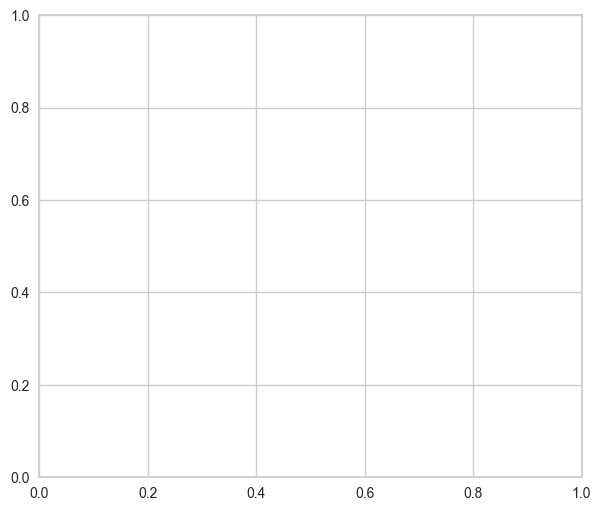

In [21]:
#評估調整後的模型
evaluate_model(model1_3)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

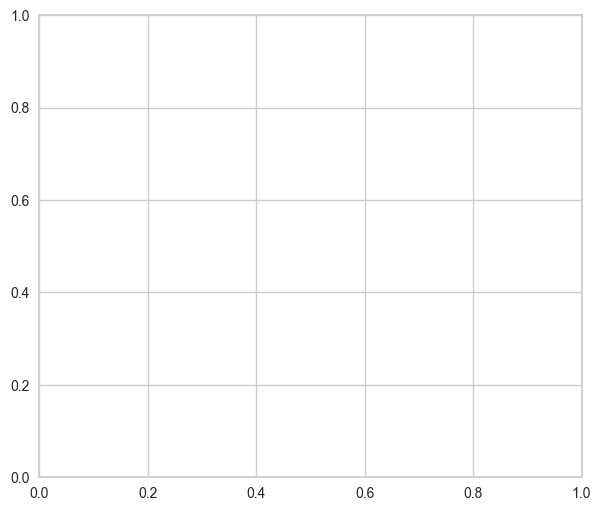

In [22]:
evaluate_model(rf)

In [21]:
#模型集成
#使用Bagging集成多個最優分類器
#ensemble_model = ensemble_model(model1_2, method='Bagging')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9050,0.7228,0.0000,0.0000,0.0000,-0.0029,-0.0123
1,0.9064,0.6549,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9064,0.6681,0.0156,0.5000,0.0303,0.0248,0.0756
3,0.9064,0.6681,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.9064,0.6448,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9079,0.6657,0.0156,1.0000,0.0308,0.0280,0.1191
6,0.9064,0.6589,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9079,0.7000,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9078,0.6641,0.0000,0.0000,0.0000,0.0000,0.0000


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

In [17]:
#模型評估
from sklearn.metrics import classification_report, confusion_matrix

#預測測試集數據
predictions = predict_model(stacker_model, data=test_data)

#計算混淆矩陣和分類報告
cm = confusion_matrix(predictions['GDM'], predictions['prediction_label'])
report = classification_report(predictions['GDM'], predictions['prediction_label'])

#輸出混淆矩陣和分類報告
print("Confusion matrix:")
print(cm)
print("Classification report:")
print(report)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9713,0.8849,0.6833,1.0000,0.8118,0.7969,0.8139


Confusion matrix:
[[2222    0]
 [  70  151]]
Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2222
           1       1.00      0.68      0.81       221

    accuracy                           0.97      2443
   macro avg       0.98      0.84      0.90      2443
weighted avg       0.97      0.97      0.97      2443



In [ ]:
#模型解釋性分析
#解釋模型中各個特徵的重要性
interpret_model(lightgbm)
#interpret_model(lr)

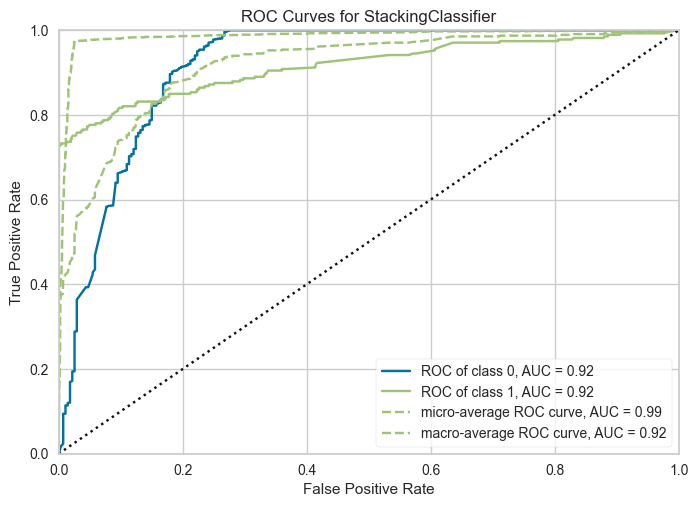

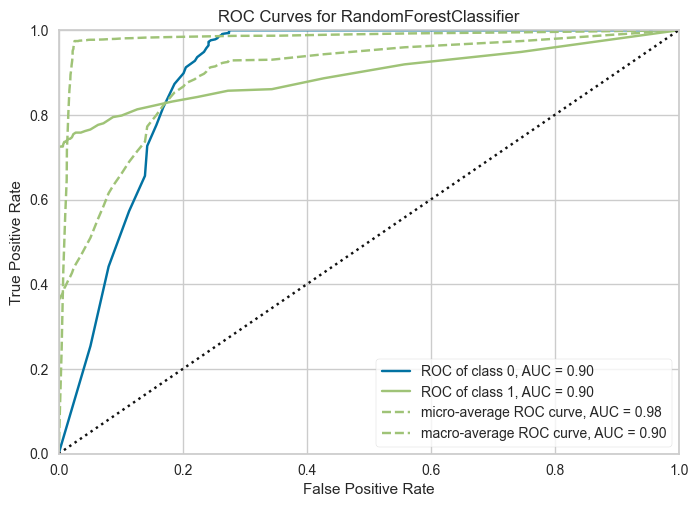

In [14]:
#繪製ROC曲線和KS曲線
plot_model(stacker_model, plot='auc')
plot_model(rf, plot='auc')
#plot_model(model1_2, plot='ks')

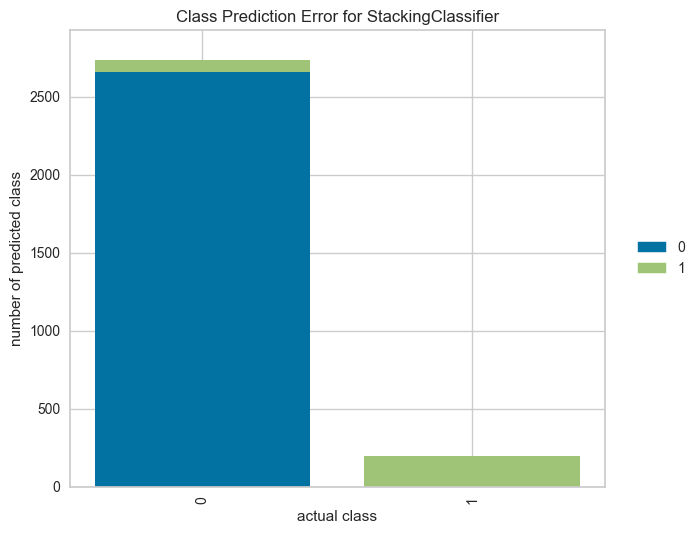

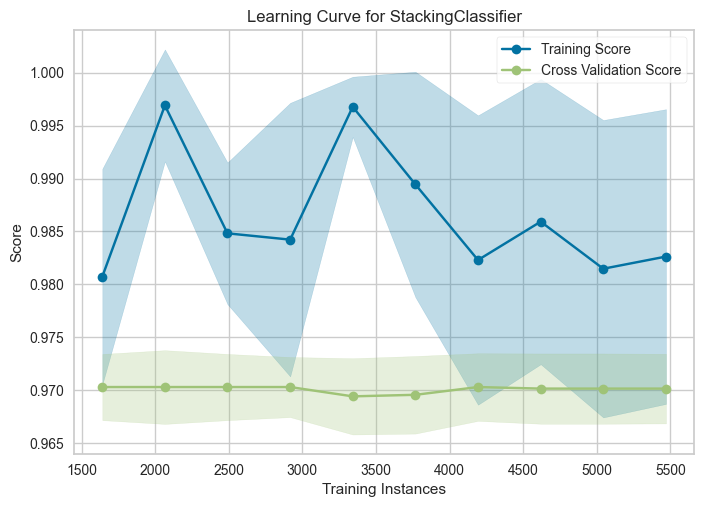

<function pycaret.classification.functional.plot_model(estimator, plot: str = 'auc', scale: float = 1, save: bool = False, fold: Union[int, Any, NoneType] = None, fit_kwargs: Optional[dict] = None, plot_kwargs: Optional[dict] = None, groups: Union[str, Any, NoneType] = None, use_train_data: bool = False, verbose: bool = True, display_format: Optional[str] = None) -> Optional[str]>

In [22]:
#研究結果分析
#繪製特徵重要性圖表
#plot_model(stacker_model, plot='feature')

#繪製錯誤分析圖表
plot_model(stacker_model, plot='error')

#繪製分類器學習曲線和驗證曲線
plot_model(stacker_model, plot='learning')
plot_model

In [15]:
summary_plot = plot_model(rf, plot='summary')

ValueError: Plot Not Available. Please see docstring for list of available Plots.